In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv(r"C:\Users\SHIVANI\OneDrive\Attachments\ChurnGuard AI — Customer Churn Prediction & Retention System\WA_Fn-UseC_-Telco-Customer-Churn-selected-columns.csv")

In [5]:
print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No


In [6]:
# Basic information about dataset

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (7043, 10)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity']

Data Types:
customerID           str
gender               str
SeniorCitizen      int64
Partner              str
Dependents           str
tenure             int64
PhoneService         str
MultipleLines        str
InternetService      str
OnlineSecurity       str
dtype: object

Missing Values:
customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

Duplicate Rows:
0


In [7]:
# Statistical summary

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# First 10 rows

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes


In [9]:
# Last columns and their values

print(df.tail())

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  
7038          Yes               Yes             DSL            Yes  
7039          Yes               Yes     Fiber optic             No  
7040           No  No phone service             DSL            Yes  
7041          Yes               Yes     Fiber optic             No  
7042          Yes                No     Fiber optic            Yes  


In [10]:
print("Number of columns:", len(df.columns))

for i, col in enumerate(df.columns, start=1):
    print(i, "→", col)

Number of columns: 10
1 → customerID
2 → gender
3 → SeniorCitizen
4 → Partner
5 → Dependents
6 → tenure
7 → PhoneService
8 → MultipleLines
9 → InternetService
10 → OnlineSecurity


In [11]:
print("Churn column present:", "Churn" in df.columns)

Churn column present: False


In [12]:
df2 = pd.read_csv(r"C:\Users\SHIVANI\OneDrive\Attachments\ChurnGuard AI — Customer Churn Prediction & Retention System\customer_churn.csv")

In [15]:
print("Shape:", df2.shape)
print("\nColumns:")
print(df2.columns.tolist())

print("\nTarget distribution:")
print(df2["Churn"].value_counts())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [16]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [17]:
print(df.dtypes)

customerID           str
gender               str
SeniorCitizen      int64
Partner              str
Dependents           str
tenure             int64
PhoneService         str
MultipleLines        str
InternetService      str
OnlineSecurity       str
dtype: object


In [18]:
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate customer IDs: 0


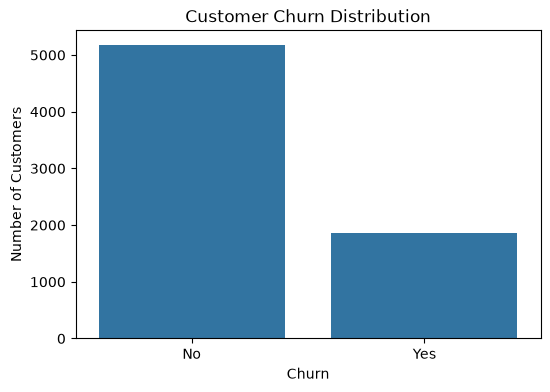

In [25]:
# Churn visualization

plt.figure(figsize=(6, 4))

sns.countplot(data=df2, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
# Categorical columns

categorical_cols = df2.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\SHIVANI\AppData\Local\Temp\ipykernel_26896\2262239441.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df2.select_dtypes(include=["object"]).columns


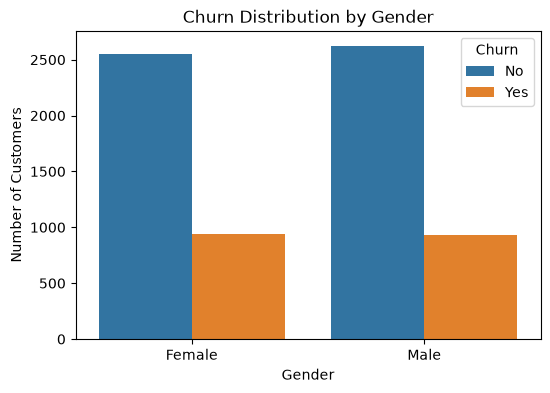

In [26]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df2, x="gender", hue="Churn")

plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

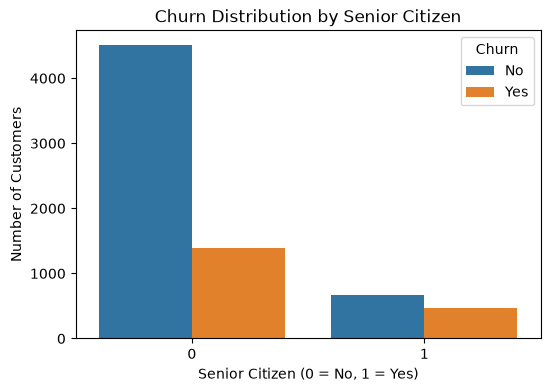

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df2, x="SeniorCitizen", hue="Churn")

plt.title("Churn Distribution by Senior Citizen")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

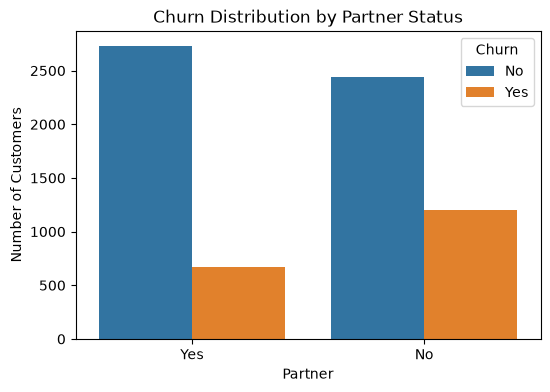

In [28]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df2, x="Partner", hue="Churn")

plt.title("Churn Distribution by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

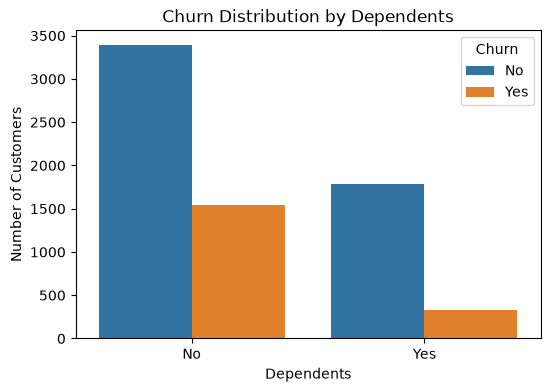

In [29]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df2, x="Dependents", hue="Churn")

plt.title("Churn Distribution by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

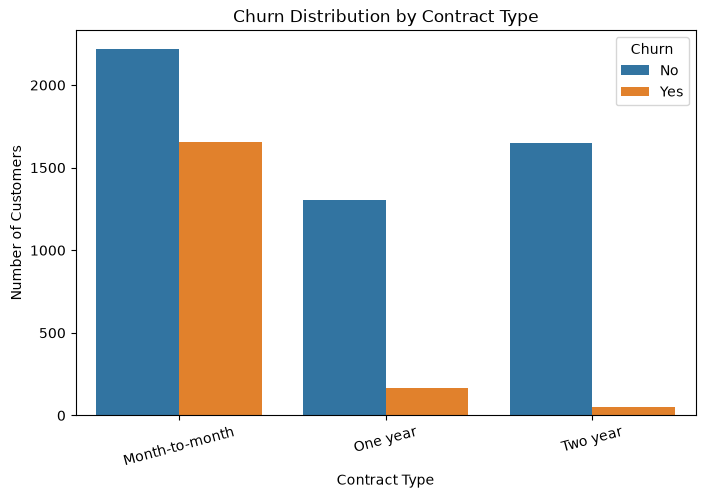

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df2, x="Contract", hue="Churn")

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

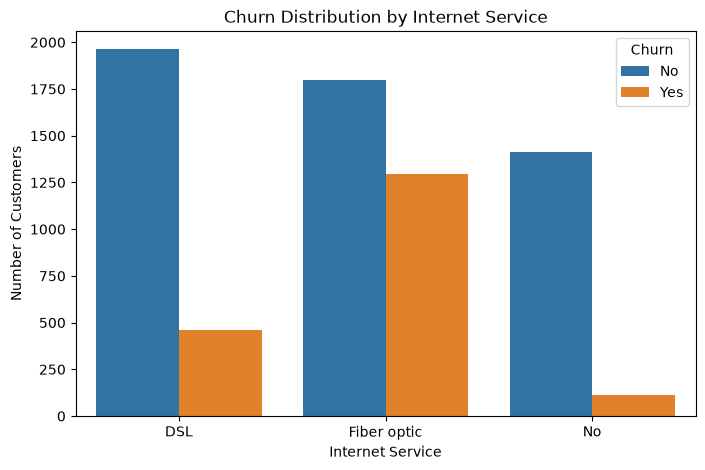

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df2, x="InternetService", hue="Churn")

plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

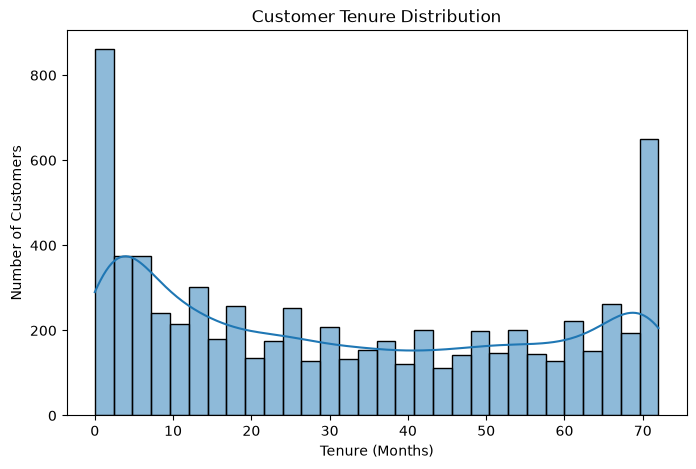

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

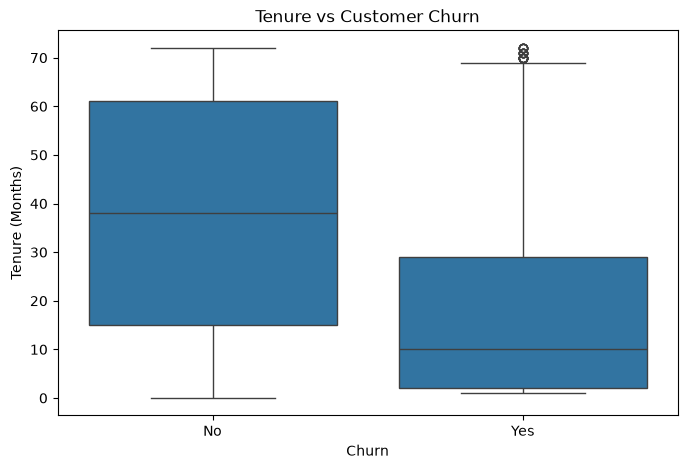

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df2, x="Churn", y="tenure")

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [37]:
df2["tenure_group"] = pd.cut(
    df2["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"]
)

print(pd.crosstab(
    df2["tenure_group"],
    df2["Churn"],
    normalize="index"
).round(3) * 100)

Churn           No   Yes
tenure_group            
0-12 Months   52.6  47.4
13-24 Months  71.3  28.7
25-48 Months  79.6  20.4
49-72 Months  90.5   9.5


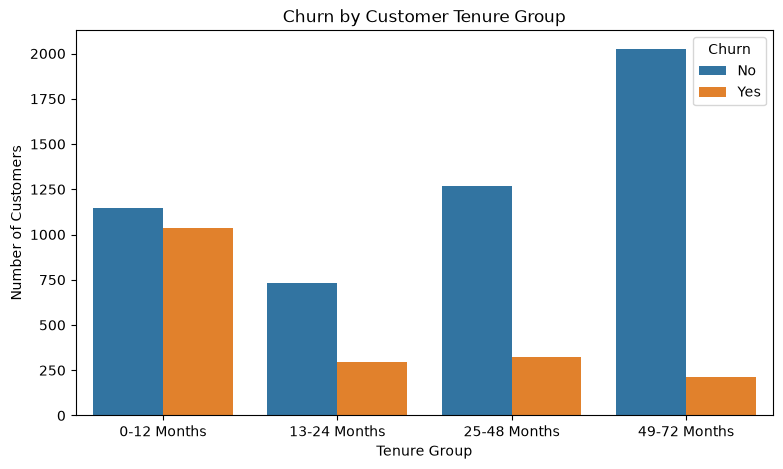

In [39]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df2, x="tenure_group", hue="Churn")

plt.title("Churn by Customer Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()

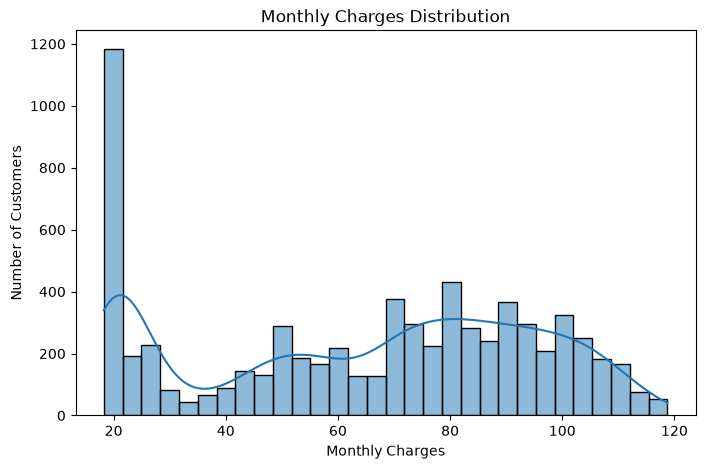

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df2, x="MonthlyCharges", bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

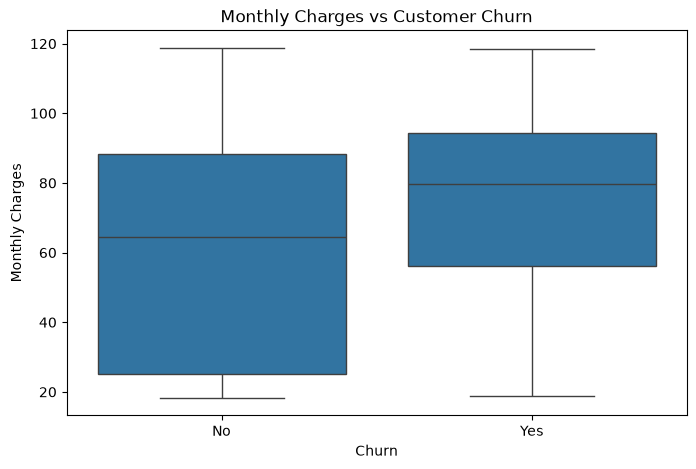

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df2, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [45]:
df2["TotalCharges"] = pd.to_numeric(
    df2["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges:", df2["TotalCharges"].isnull().sum())

Missing TotalCharges: 11


In [46]:
df2[df2["TotalCharges"].isnull()][
    ["customerID", "tenure", "TotalCharges", "Churn"]
]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,NaN,No
753,3115-CZMZD,0,NaN,No
936,5709-LVOEQ,0,NaN,No
1082,4367-NUYAO,0,NaN,No
1340,1371-DWPAZ,0,NaN,No
3331,7644-OMVMY,0,NaN,No
3826,3213-VVOLG,0,NaN,No
4380,2520-SGTTA,0,NaN,No
5218,2923-ARZLG,0,NaN,No
6670,4075-WKNIU,0,NaN,No


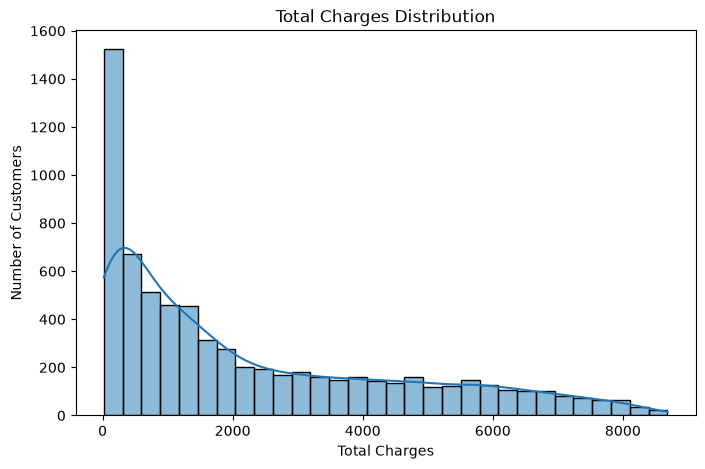

In [48]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df2, x="TotalCharges", bins=30, kde=True)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

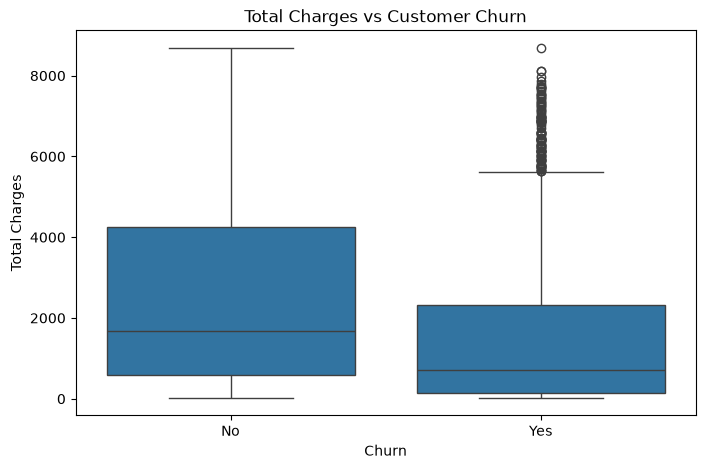

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df2, x="Churn", y="TotalCharges")

plt.title("Total Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [51]:
contract_churn = pd.crosstab(
    df2["Contract"],
    df2["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [53]:
internet_churn = pd.crosstab(
    df2["InternetService"],
    df2["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


In [55]:
payment_churn = pd.crosstab(
    df2["PaymentMethod"],
    df2["Churn"],
    normalize="index"
) * 100

print(payment_churn.round(2))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


In [57]:
# Final EDA Summary

print("===== CHURNGUARD-AI EDA SUMMARY =====\n")

print("Dataset Shape:", df.shape)

print("\nTarget Distribution:")
print(df2["Churn"].value_counts())

print("\nTarget Percentage:")
print((df2["Churn"].value_counts(normalize=True) * 100).round(2))

print("\nNumerical Columns:")
print(df2.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical Columns:")
print(df2.select_dtypes(include=["object"]).columns.tolist())

===== CHURNGUARD-AI EDA SUMMARY =====

Dataset Shape: (7043, 11)

Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\SHIVANI\AppData\Local\Temp\ipykernel_26896\1667446282.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df2.select_dtypes(include=["object"]).columns.tolist())
